In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("US_Accidents_March23.csv")

In [3]:
print(data.head())
print(data.info())

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

In [7]:

data["Start_Time"] = pd.to_datetime(data["Start_Time"], errors='coerce')


In [8]:
data["Hour"] = data["Start_Time"].dt.hour

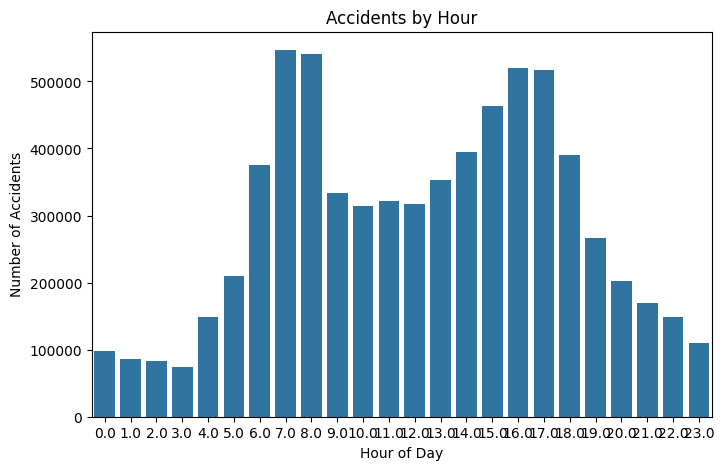

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="Hour", data=data)

plt.title("Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")

plt.show()

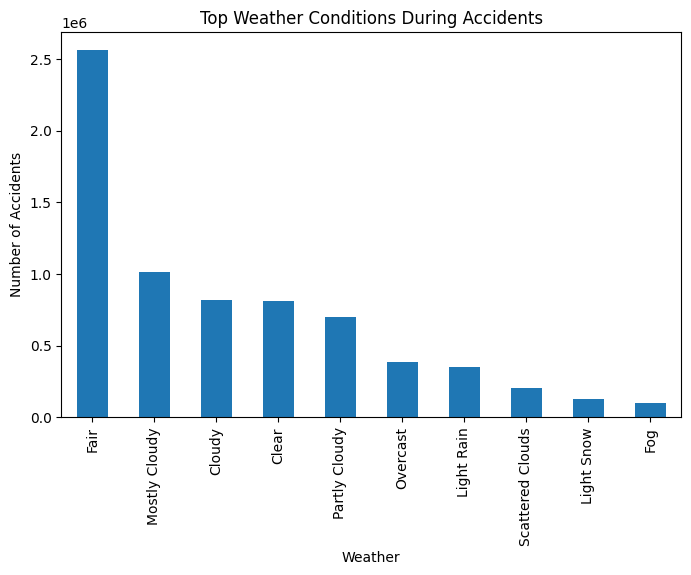

In [12]:
weather = data["Weather_Condition"].value_counts().head(10)

plt.figure(figsize=(8,5))
weather.plot(kind="bar")

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Weather")
plt.ylabel("Number of Accidents")

plt.show()

In [13]:
road_factors = ["Bump","Crossing","Junction","Traffic_Signal","Stop"]

for factor in road_factors:
    if factor in data.columns:
        print("\n", factor)
        print(data[factor].value_counts())


 Bump
Bump
False    7724880
True        3514
Name: count, dtype: int64

 Crossing
Crossing
False    6854631
True      873763
Name: count, dtype: int64

 Junction
Junction
False    7157052
True      571342
Name: count, dtype: int64

 Traffic_Signal
Traffic_Signal
False    6584622
True     1143772
Name: count, dtype: int64

 Stop
Stop
False    7514023
True      214371
Name: count, dtype: int64


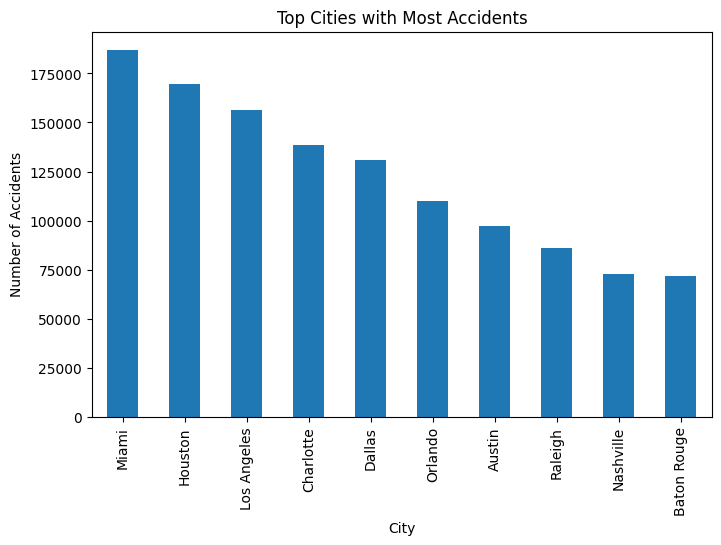

In [14]:
cities = data["City"].value_counts().head(10)

plt.figure(figsize=(8,5))
cities.plot(kind="bar")

plt.title("Top Cities with Most Accidents")
plt.xlabel("City")
plt.ylabel("Number of Accidents")

plt.show()